# Nonlinear least squares with variable projection

Many curve-fitting problems are *separable*: the model is linear in some parameters and nonlinear in others. A classic example is a sum of exponentials,

$$y(t) \approx \sum_{j=1}^n c_j\, e^{-k_j t},$$

which is linear in the amplitudes $c$ but nonlinear in the decay rates $k$. Collecting the basis functions into a matrix $\Phi(k)_{ij} = e^{-k_j t_i}$, the model is $\Phi(k)\,c$ and the least-squares problem is

$$\min_{k,\,c}\; \tfrac{1}{2}\,\lVert \Phi(k)\,c - y \rVert^2.$$

**Variable projection** ([Golub & Pereyra, 1973](https://doi.org/10.1137/0710036)) eliminates the linear parameters. For any fixed $k$ the optimal amplitudes are $c^\star(k) = \Phi(k)^\dagger y$, so substituting them back gives a residual in the nonlinear parameters alone:

$$r(k) = y - \Phi(k)\,\Phi(k)^\dagger\, y = (I - P(k))\,y, \qquad P(k) = \Phi(k)\,\Phi(k)^\dagger.$$

Here $P(k)$ is the orthogonal projector onto $\mathrm{range}\,\Phi(k)$, which is exactly what [`lineax.project`][] returns — together with its efficient gradient. So $r(k)$ is a one-liner that we can hand straight to a nonlinear least-squares solver.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import lineax as lx
import matplotlib.pyplot as plt
import optimistix as optx


jax.config.update("jax_enable_x64", True)

# Synthetic data: a sum of two decaying exponentials, plus a little noise.
t = jnp.linspace(0.0, 4.0, 200)
true_rates = jnp.array([0.5, 3.0])  # nonlinear parameters, k
true_amplitudes = jnp.array([2.0, 1.0])  # linear parameters, c


def features(rates):
    # Phi(k): each column is a basis function exp(-k_j t); shape (len(t), len(rates)).
    return jnp.exp(-t[:, None] * rates[None, :])


y = features(true_rates) @ true_amplitudes + 0.01 * jr.normal(jr.PRNGKey(0), t.shape)

The projector is built from the operator $\Phi(k)$. Here $\Phi(k)$ is dense so we wrap it in a [`lineax.MatrixLinearOperator`][], but [`lineax.project`][] accepts any [`lineax.AbstractLinearOperator`][] — so for a large-scale problem $\Phi$ could be matrix-free.

We solve with [`lineax.SVD`][]: during the fit the optimiser may try rates that nearly coincide, making $\Phi$ rank-deficient, and the SVD pseudoinverse handles that gracefully (the default full-rank solver would error). Eliminating the amplitudes then takes a single line, and we fit the rates with [Optimistix](https://github.com/patrick-kidger/optimistix).

In [2]:
def varpro_residuals(rates, args):
    operator = lx.MatrixLinearOperator(features(rates))
    return y - lx.project(operator, lx.SVD()).mv(y)  # (I - P) y, amplitudes eliminated


solver = optx.LevenbergMarquardt(rtol=1e-8, atol=1e-8)
init_rates = jnp.array([1.0, 2.0])
solution = optx.least_squares(varpro_residuals, solver, init_rates, max_steps=100)

fitted_rates = solution.value
# Recover the amplitudes for the fitted rates with a single linear solve.
fitted_operator = lx.MatrixLinearOperator(features(fitted_rates))
fitted_amplitudes = lx.linear_solve(fitted_operator, y, lx.SVD()).value
print("true rates:       ", true_rates)
print("fitted rates:     ", fitted_rates)
print("fitted amplitudes:", fitted_amplitudes)

true rates:        [0.5 3. ]
fitted rates:      [0.50192609 3.03565001]
fitted amplitudes: [2.00523518 0.99997341]


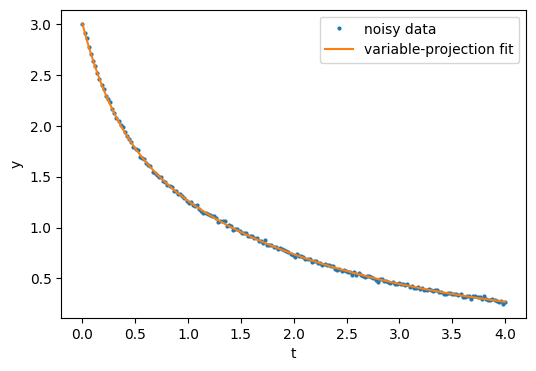

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(t, y, ".", markersize=4, label="noisy data")
plt.plot(t, features(fitted_rates) @ fitted_amplitudes, label="variable-projection fit")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.show()

## Why eliminate the linear parameters?

Variable projection optimises only the $n$ nonlinear rates instead of all $2n$ parameters at once, and the reduced problem is better conditioned — so a second-order solver reaches the solution in far fewer steps. Below we compare against fitting all parameters $(k, c)$ jointly. Both start from the same rates, and to be fair the joint solver is given the best amplitudes for that initial guess, $c_0 = \Phi(k_0)^\dagger y$.

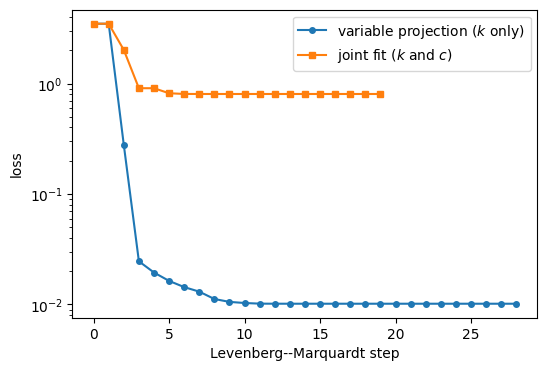

In [4]:
def joint_residuals(params, args):
    rates, amplitudes = params
    operator = lx.MatrixLinearOperator(features(rates))
    return operator.mv(amplitudes) - y


def loss_history(residual_fn, y0, max_steps=40):
    # Step the solver manually (the standard Optimistix pattern) to record the loss
    # after each Levenberg-Marquardt step. Optimistix functions return (output, aux).
    fn = lambda z, args: (residual_fn(z, args), None)
    args, options, tags = None, {}, frozenset()
    f_struct, aux_struct = jax.eval_shape(lambda: fn(y0, args))
    step = eqx.filter_jit(
        eqx.Partial(solver.step, fn=fn, args=args, options=options, tags=tags)
    )
    terminate = eqx.filter_jit(
        eqx.Partial(solver.terminate, fn=fn, args=args, options=options, tags=tags)
    )

    y = y0
    state = solver.init(fn, y, args, options, f_struct, aux_struct, tags)
    losses = [0.5 * jnp.sum(fn(y, args)[0] ** 2)]
    done, _ = terminate(y=y, state=state)
    while not done and len(losses) <= max_steps:
        y, state, _ = step(y=y, state=state)
        losses.append(0.5 * jnp.sum(fn(y, args)[0] ** 2))
        done, _ = terminate(y=y, state=state)
    return jnp.array(losses)


# The joint fit needs an initial amplitude guess; give it the best amplitudes for
# `init_rates` (a single linear solve) so the comparison is fair.
init_operator = lx.MatrixLinearOperator(features(init_rates))
init_amplitudes = lx.linear_solve(init_operator, y, lx.SVD()).value

varpro_loss = loss_history(varpro_residuals, init_rates)
joint_loss = loss_history(joint_residuals, (init_rates, init_amplitudes))

plt.figure(figsize=(6, 4))
plt.semilogy(varpro_loss, "-o", markersize=4, label="variable projection ($k$ only)")
plt.semilogy(joint_loss, "-s", markersize=4, label="joint fit ($k$ and $c$)")
plt.xlabel("Levenberg--Marquardt step")
plt.ylabel("loss")
plt.legend()
plt.show()

Variable projection reaches the noise floor in a handful of steps, while the joint fit — with twice as many parameters and a more ill-conditioned landscape — lags well behind. This conditioning advantage also tends to widen the basin of convergence, making the fit less sensitive to the initial guess; see [Golub & Pereyra (1973)](https://doi.org/10.1137/0710036) and [O'Leary & Rust (2013)](https://doi.org/10.1007/s10589-012-9492-9).